In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score,silhouette_samples

In [0]:
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

In [0]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width",180)

In [0]:
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes", #usage intensity
    "sessions_per_day",        #frequency
    "days_active_last_30",     #consistencyspotify_user_behavior = spark.table(
    "avg_session_minutes",     #depth
    "skip_rate",               #content friction
    "liked_songs_pct",         #positive engagement
    "ads_skipped_pct",         #monetization friction
]

In [0]:
base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()
K=4
X2 = base[CLUSTER_FEATURES_V1].copy()
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2 = pd.DataFrame(X2_scaled, columns = CLUSTER_FEATURES_V1, index = base.index)

km2= KMeans (
    n_clusters= K,
    random_state=42,
    n_init=20,
    max_iter = 300
)

In [0]:
labels2 = km2.fit_predict(X2)
inertia2 = km2.inertia_
sill_avg_2 = silhouette_score(X2, labels2)
base_iter2 = base.copy()
base_iter2["cluster"] = labels2
print(f"\nIteration 2 results | k={K}")
print("Inertia:", round(inertia2,2))
print("Silhouette :", round(sill_avg_2,3))



Iteration 2 results | k=4
Inertia: 488693.28
Silhouette : 0.152


In [0]:
sizes2 = base_iter2["cluster"].value_counts().sort_index()
means2 = (
    base_iter2.groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

In [0]:
profile2 = means2.copy()
profile2.insert(0,"cluster_size",sizes2)
print("\n Cluster Profile (means, original scale) -- Iteration 2 (StandardScalar Labels):")
display(profile2)


 Cluster Profile (means, original scale) -- Iteration 2 (StandardScalar Labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
41989,26.363498706401234,1.149,17.136001362774667,23.80678715612816,0.298,0.2117172841338125,0.5712346755812213
42596,26.579145618717092,1.151,24.4640926403915,23.922243942102167,0.382,0.34692098103096813,0.47680238777454587
17315,87.15512848679438,1.175,22.38228236728379,76.65279803210426,0.267,0.3084801295676096,0.6242580631223174
6100,130.31511690745427,3.875,22.525082384374233,34.118920886915554,0.285,0.3115689215942582,0.5945072869797571


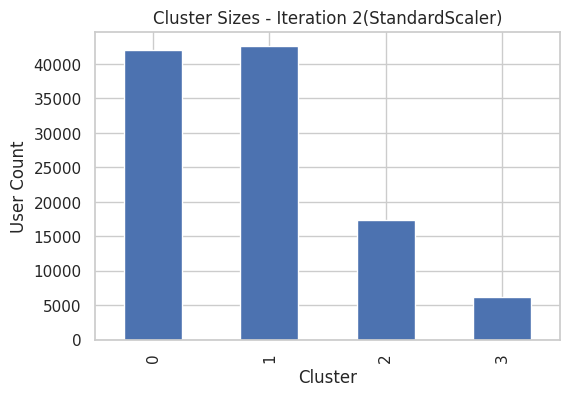

In [0]:
plt.figure(figsize=(6,4))
base_iter2["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 2(StandardScaler)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

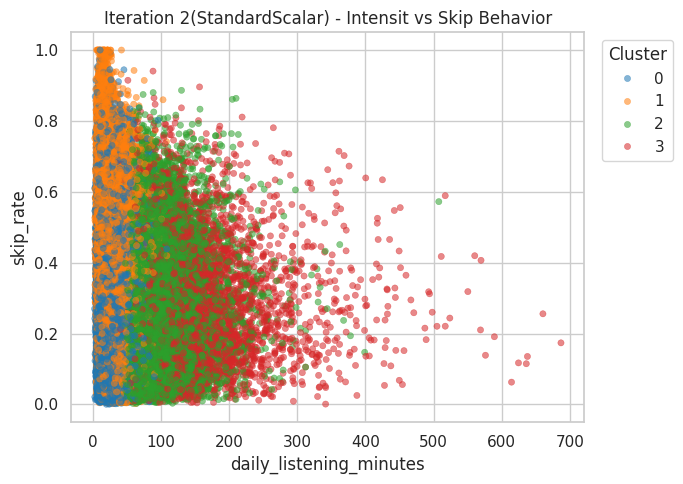

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data = base_iter2,
    x = "daily_listening_minutes",
    y = "skip_rate",
    hue = "cluster",
    palette = "tab10",
    s= 20,
    alpha = 0.55,
    edgecolor = None
    )
plt.title("Iteration 2(StandardScalar) - Intensit vs Skip Behavior")
plt.legend(title="Cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()


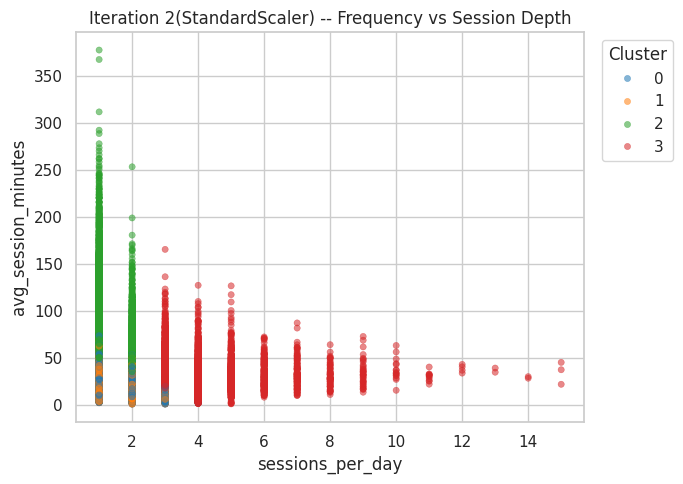

In [0]:
#frequency vs Session depth
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter2,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration 2(StandardScaler) -- Frequency vs Session Depth")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

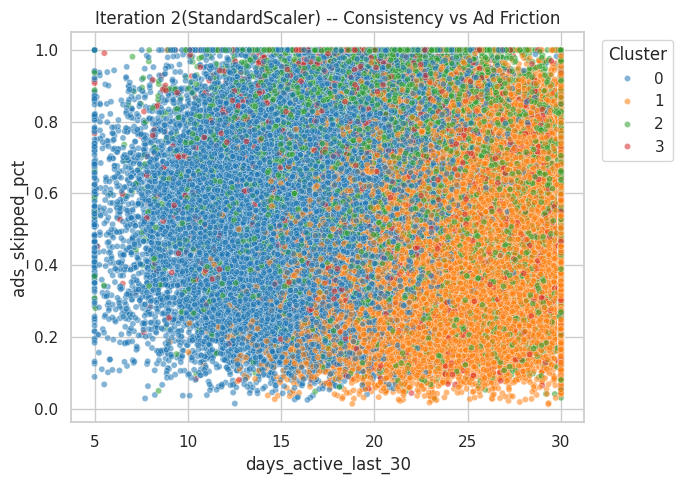

In [0]:
#Consisitency vs Ad Friction
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter2,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
)
plt.title("Iteration 2(StandardScaler) -- Consistency vs Ad Friction")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

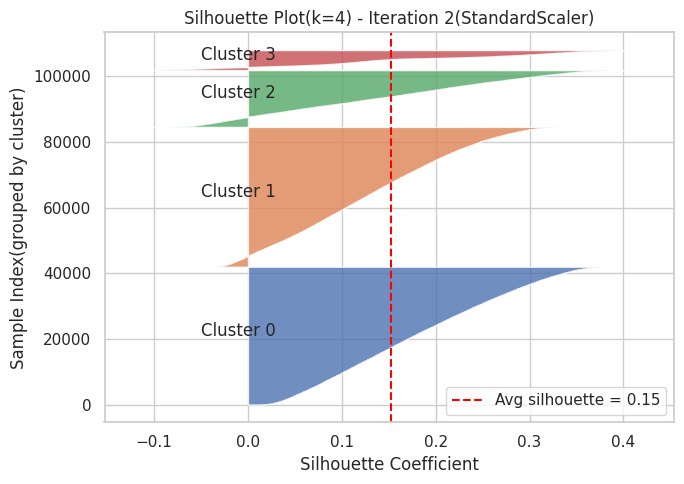

Iteration 1 Avg Silhouette 0.152


In [0]:
# Silhouette Plot
sil_values_2 = silhouette_samples(X2, labels2)
sill_avg_2 = silhouette_score(X2, labels2)
plt.figure(figsize=(7,5))
y_lower = 0


vals0 = sil_values_2[labels2 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals0,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size0,
    "Cluster 0 "
)
y_lower = y_upper 


vals1 = sil_values_2[labels2 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size1,
    "Cluster 1 "
)
y_lower = y_upper 


vals2 = sil_values_2[labels2 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals2,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size2,
    "Cluster 2 "
)
y_lower = y_upper 


vals3 = sil_values_2[labels2 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals3,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size3,
    "Cluster 3 "
)
y_lower = y_upper 


plt.axvline(
    x=sill_avg_2,
    color="red",
    linestyle="--",
    label = f"Avg silhouette = {sill_avg_2:.2f}"
)
plt.title("Silhouette Plot(k=4) - Iteration 2(StandardScaler)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 1 Avg Silhouette", round(sill_avg_2,3))